# Bmad -> Impact-T for `sc_inj`

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pytao import Tao
from impact import Impact
from impact.lattice import new_write_beam
from pmd_beamphysics import FieldMesh, single_particle
from impact import fieldmaps
import numpy as np
from copy import deepcopy
import os

In [3]:
# Nicer plotting
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Bmad 

In [4]:
MODEL = '$LCLS_LATTICE/bmad/models/sc_inj/'
SLICE = 'BEGINNING:LHBEGB'

In [5]:
%%time
INIT = f'-init {MODEL}/tao.init -noplot  -slice {SLICE} '
tao = Tao(INIT)

CPU times: user 8.97 s, sys: 93.3 ms, total: 9.07 s
Wall time: 9.07 s


# Impact

Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]


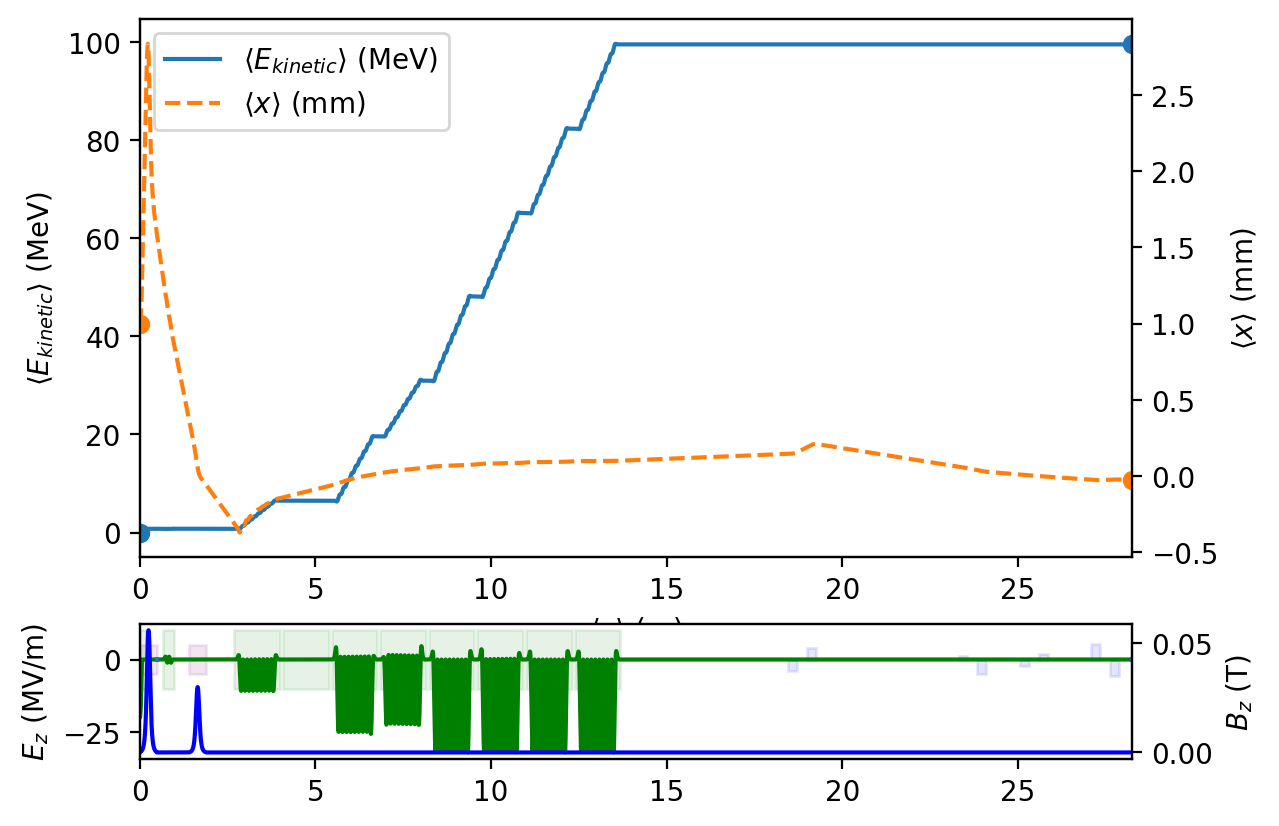

In [6]:
I = Impact.from_tao(tao)
I.track1(x0=1e-3)
I.plot('mean_kinetic_energy', y2='mean_x')

In [7]:
# Make new write_beam elements and add them to the lattice.
from impact.lattice import new_write_beam

def add_screens(impact_object, tao):

    for elename in ['YAG01B', 'CM01BEG', 'BEAM0', 'OTR0H04']:
        
        s = tao.ele_head(elename)['s']
        name = elename.split('_')[0]
        ele = new_write_beam(name=name, s=s, ref_eles=impact_object.lattice) # ref_eles will ensure that there are no naming conflicts
        impact_object.add_ele(ele)

add_screens(I, tao)

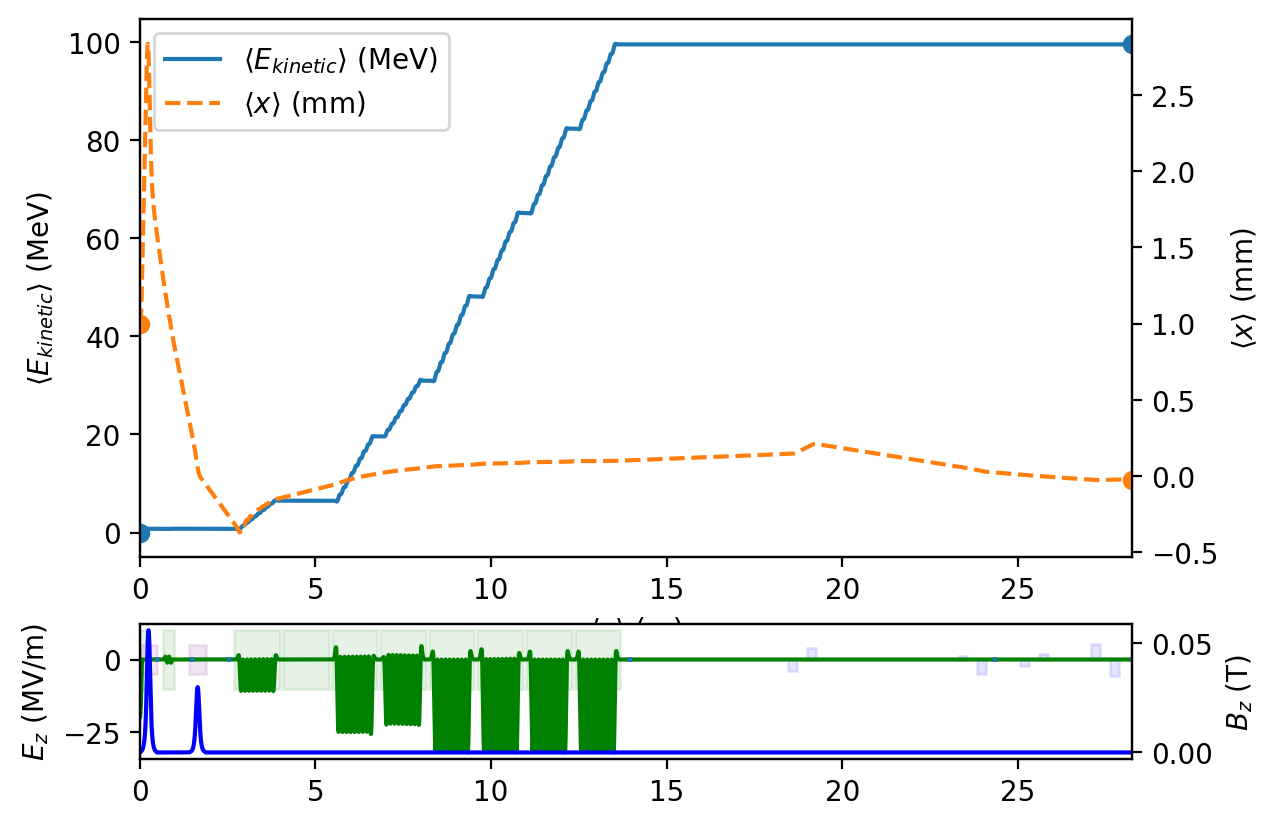

In [8]:
I.plot('mean_kinetic_energy', y2='mean_x')

# Write inputs for both styles

In [9]:
I1 = Impact.from_tao(tao, fieldmap_style = 'fourier')
add_screens(I1, tao)
OUTPATH1 = os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1')
I1.write_input(path=OUTPATH1)

Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]


In [10]:
I2 = Impact.from_tao(tao, fieldmap_style = 'derivatives')
add_screens(I2, tao)
OUTPATH2 = os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1new')
I2.write_input(path=OUTPATH2)

Nonstandard attr: componentFieldScale [1.]
Nonstandard attr: interpolationOrder [1]


# Compare Impacts

In [11]:
P0 = single_particle(pz=1e-9, x=1e-3)

In [12]:
%%time
I1 = Impact(os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1/ImpactT.in'))
Impact.command_env     = 'IMPACTT_BIN'
Impact.command_mpi_env = 'IMPACTT_MPI_BIN'

I1.initial_particles = P0


CPU times: user 780 µs, sys: 440 µs, total: 1.22 ms
Wall time: 1.01 ms


In [13]:
%%time
I1.run()

CPU times: user 160 ms, sys: 63.3 ms, total: 223 ms
Wall time: 1.05 s


In [14]:
%%time
I2 = Impact(os.path.expandvars('$LCLS_LATTICE/impact/models/sc_inj/v1new/ImpactT.in'))
Impact.command_env     = 'JI_IMPACTT_BIN'
Impact.command_mpi_env = 'JI_IMPACTT_MPI_BIN'

I2.initial_particles = P0


CPU times: user 5.01 ms, sys: 1.41 ms, total: 6.42 ms
Wall time: 5.71 ms


In [15]:
%%time
I2.run()

CPU times: user 164 ms, sys: 59.3 ms, total: 224 ms
Wall time: 1.34 s


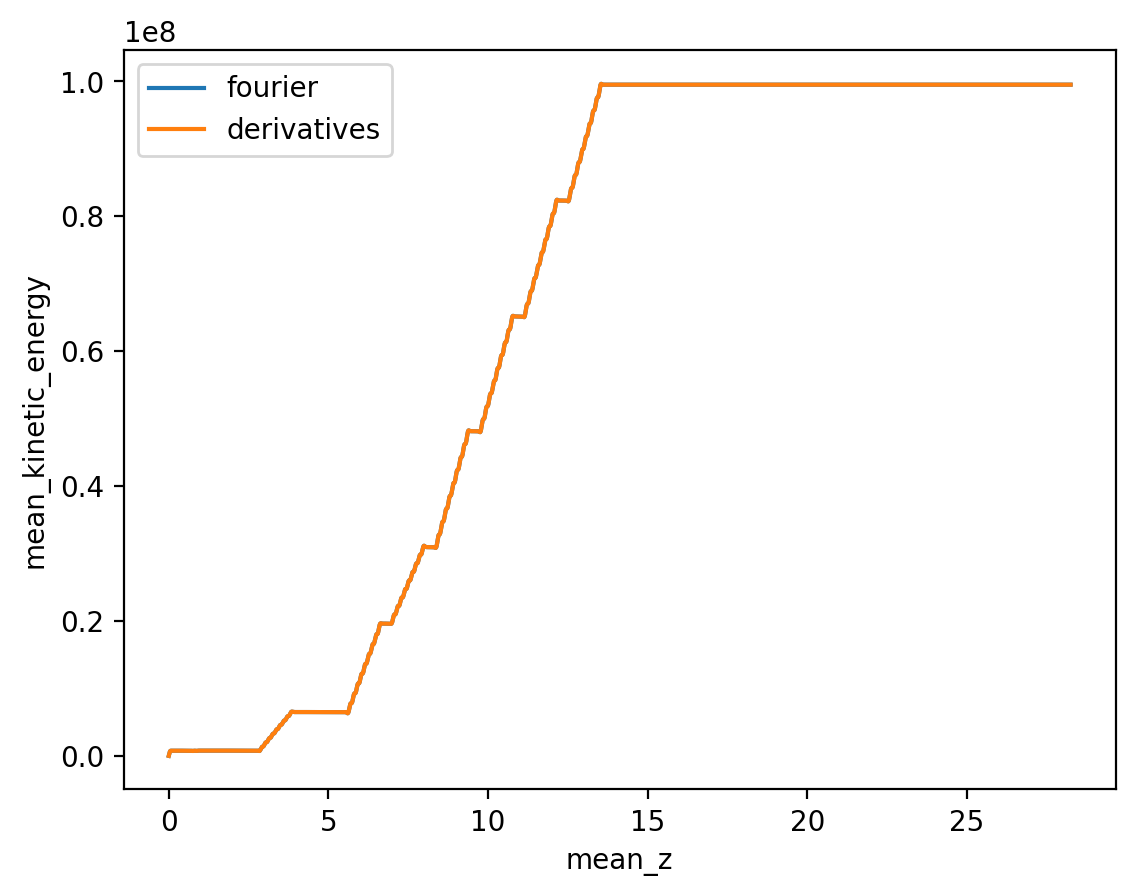

In [16]:
def compare(ykey='mean_x', xkey='mean_z'):
    
    
    fig, ax = plt.subplots()
    for name, I in ( ('fourier', I1), ('derivatives', I2)):
        x = I.stat(xkey)
        y = I.stat(ykey)
        ax.plot(x, y, label=name)
        
    plt.legend()
    ax.set_xlabel(xkey)
    ax.set_ylabel(ykey)
        
compare('mean_kinetic_energy')

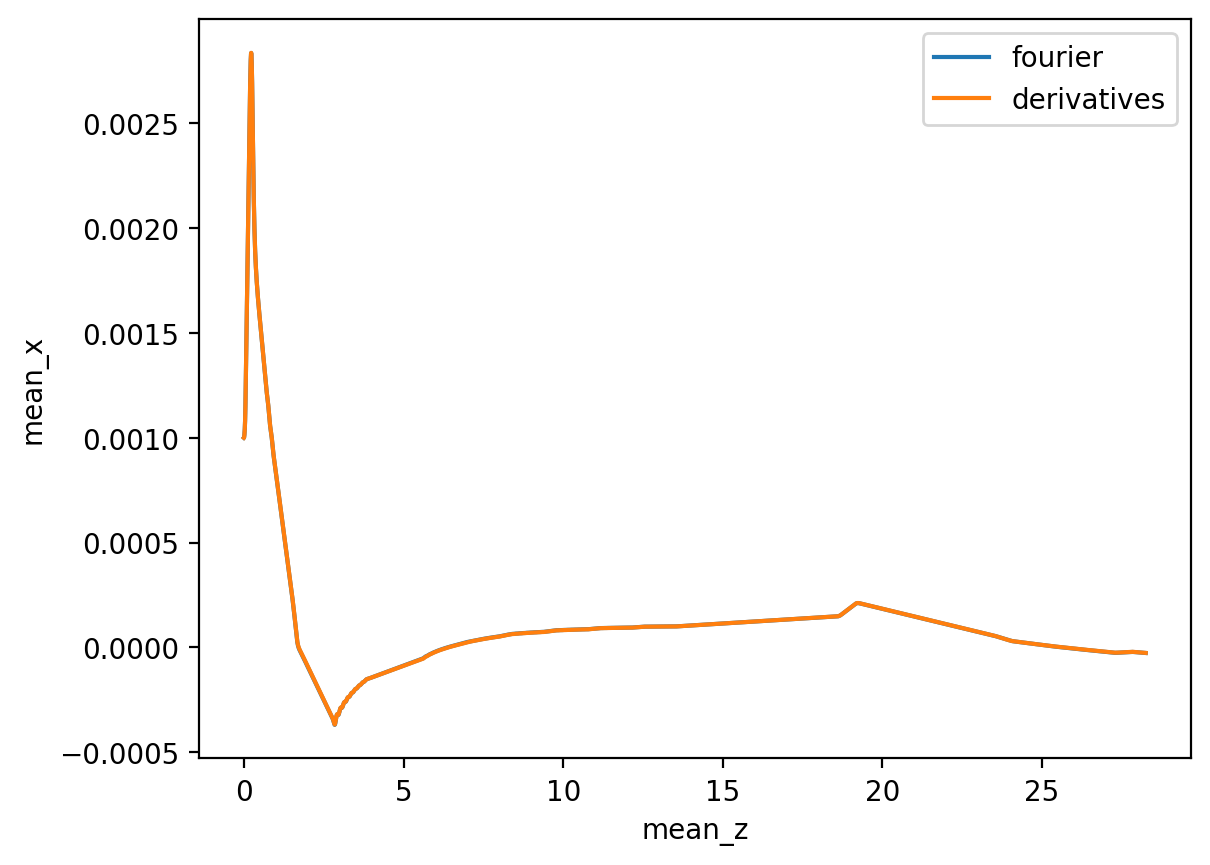

In [17]:
compare('mean_x')

# Compare Bmad vs Impact-T tracking

In [18]:
from pytao import Tao
from pytao.misc.markers import make_markers
from pmd_beamphysics import ParticleGroup
import pandas as pd
import numpy as np
import os


P0FILE = 'test.h5'
P0.write(P0FILE)

ZSTOP = I.stop

In [19]:
LATFILE = 'lat.bmad'
MARKERFILE = 'markers.bmad'

slist = np.linspace(0, ZSTOP, 250)
make_markers(slist, filename=MARKERFILE);

LAT = f"""
call, file = $LCLS_LATTICE/bmad/models/sc_inj/sc_inj.lat.bmad
call, file = {MARKERFILE}
"""

with open(LATFILE, 'w') as f:
    f.write(LAT)

In [20]:
%%time
tao = Tao(INIT + f' -lat {LATFILE}')
tao.cmd(f'set beam_init position_file = {P0FILE}')
#tao.cmd(f'set ele SOL1B x_offset = {X_OFFSET}')
#!tao.cmd(f'set ele SOL1B y_offset = {Y_OFFSET}')
tao.cmd('beamon')

CPU times: user 1min 1s, sys: 467 ms, total: 1min 2s
Wall time: 1min 2s


[]

In [21]:
ix = tao.lat_list('marker::*', 'ele.ix_ele')
df = pd.DataFrame(map(tao.bunch_params, ix))

PG1 = [ ParticleGroup(data=tao.bunch_data(i)) for i in ix]
len(PG1)

275

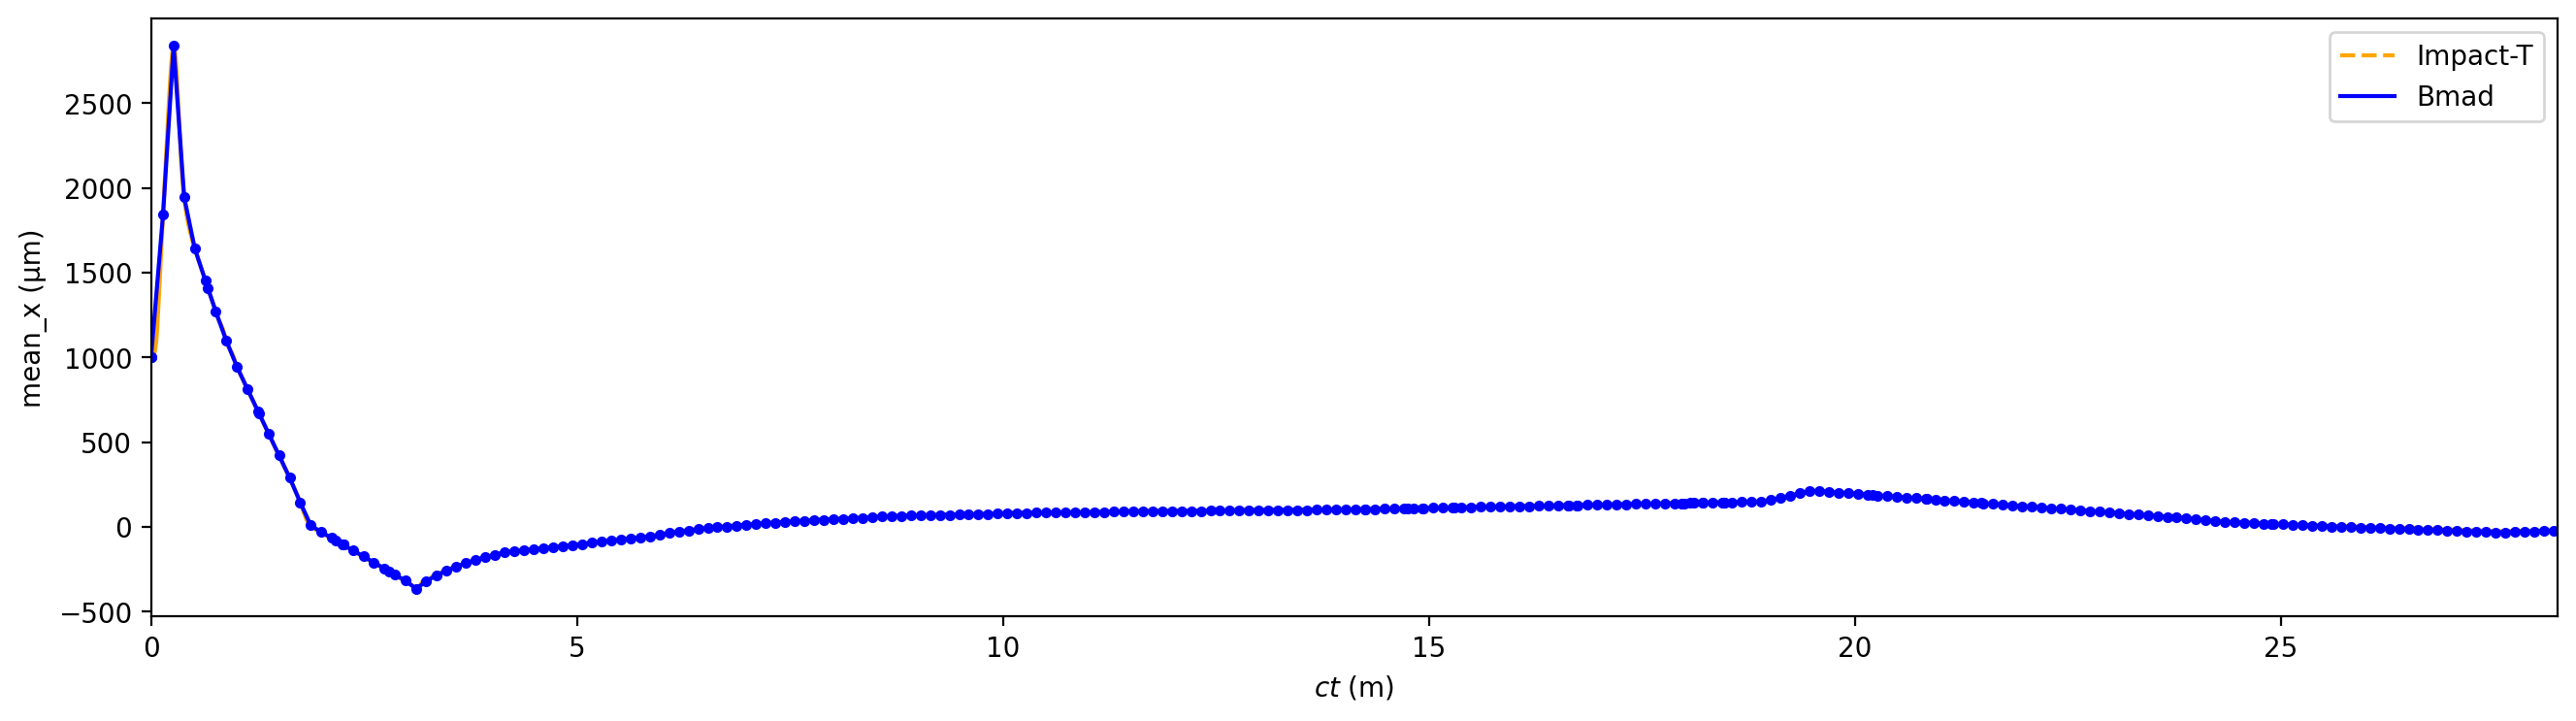

In [22]:
# Traces can be made by gathering the coordinate arrays

from matplotlib.lines import Line2D


def compare(
    ykey = 'mean_x',
    yscale = 1e6,
    yunit = r'µm'):
    
    fig, ax = plt.subplots(figsize=(16,4))
    ylabel = f'{ykey} ({yunit})'
    
    ax.plot(
        I.stat('t')*299792458,
        I.stat(ykey)*yscale,
        color='orange'
    )
        
    
    ax.plot(
        [P.t*299792458 for P in  PG1],
        [P[ykey]*yscale  for P in  PG1], color='blue', label='Bmad', marker='.',
    )
    
    ax.set_xlim(0, ZSTOP)
    #ax.set_ylim(0.5e6, 2e6)
    
    custom_lines = [Line2D([0], [0], color='orange', linestyle='--'),
                    Line2D([0], [0], color='blue')]
    ax.legend(custom_lines, ['Impact-T', 'Bmad'])
    
    ax.set_xlabel(f'$ct$ (m)')
    ax.set_ylabel(ylabel)
    #ax.set_ylim(0, 1200)
    #plt.title('Astra (red), Bmad (Blue) with fine Astra fieldmap')
    plt.savefig(f'sc_inj-Bmad-Impact-comparison-{ykey}.png', bbox_inches='tight', dpi=150)
compare()

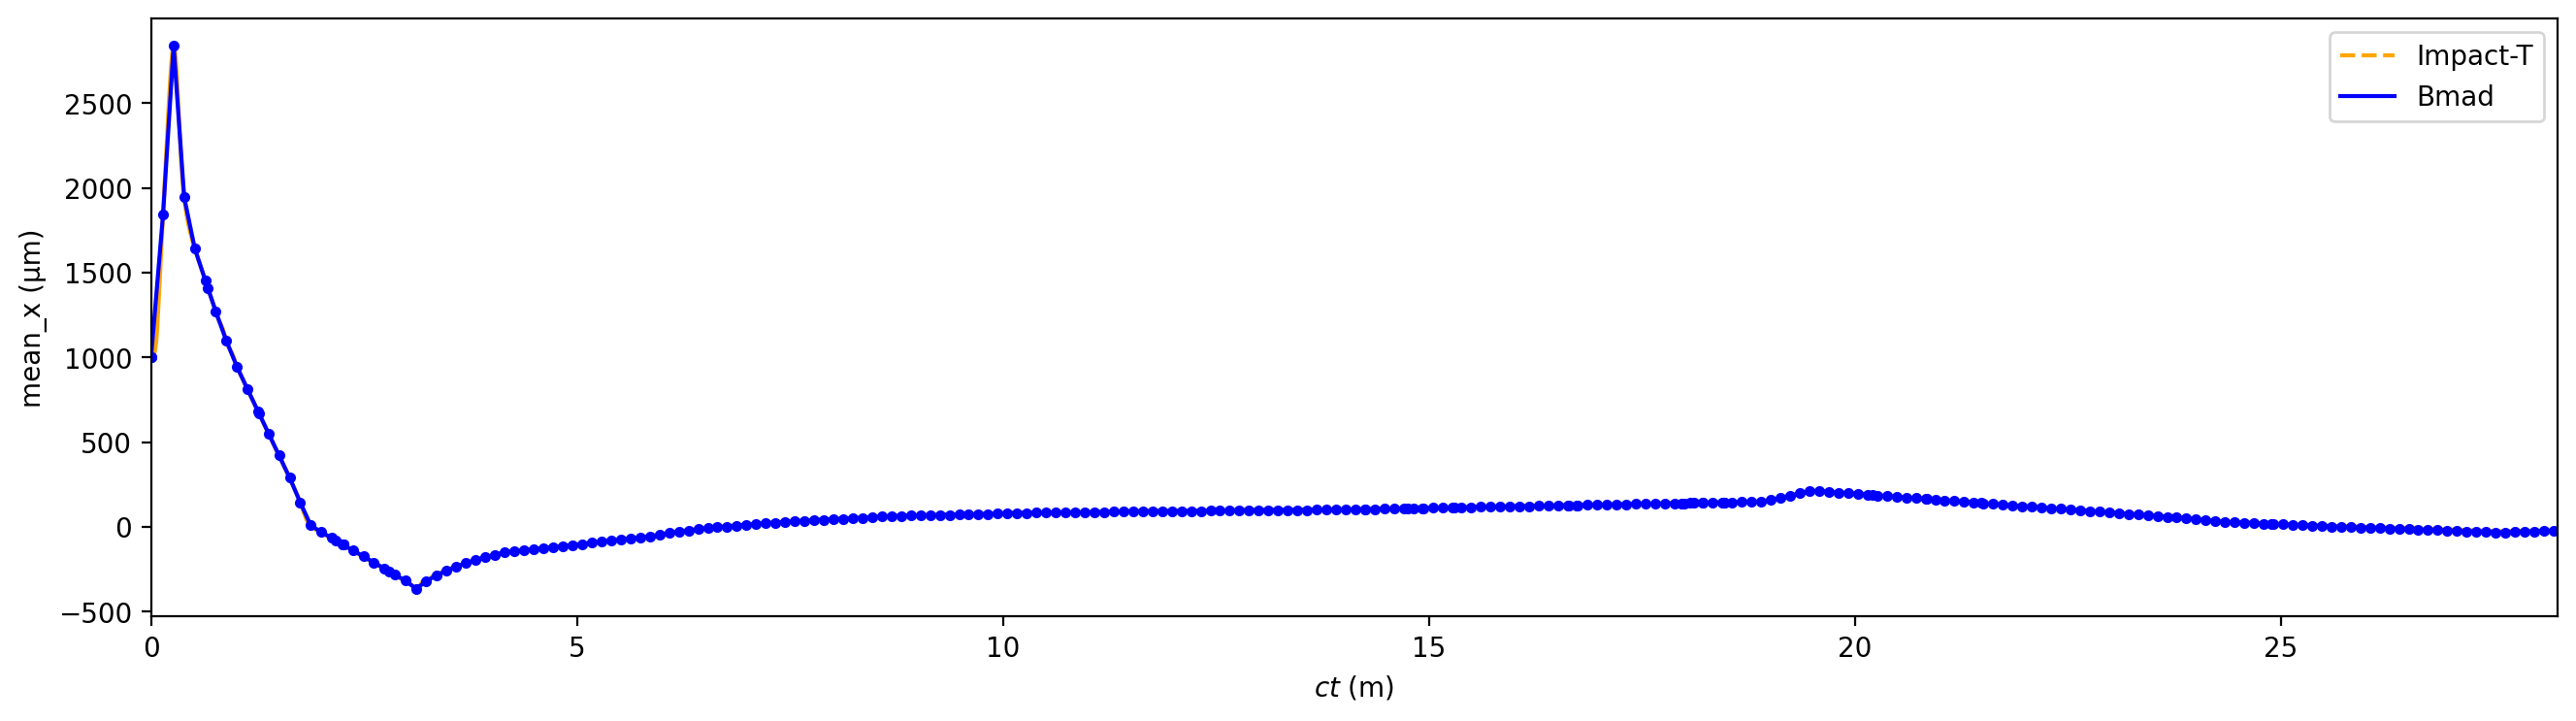

In [23]:
compare('mean_x', yscale = 1e6, yunit = r'µm')

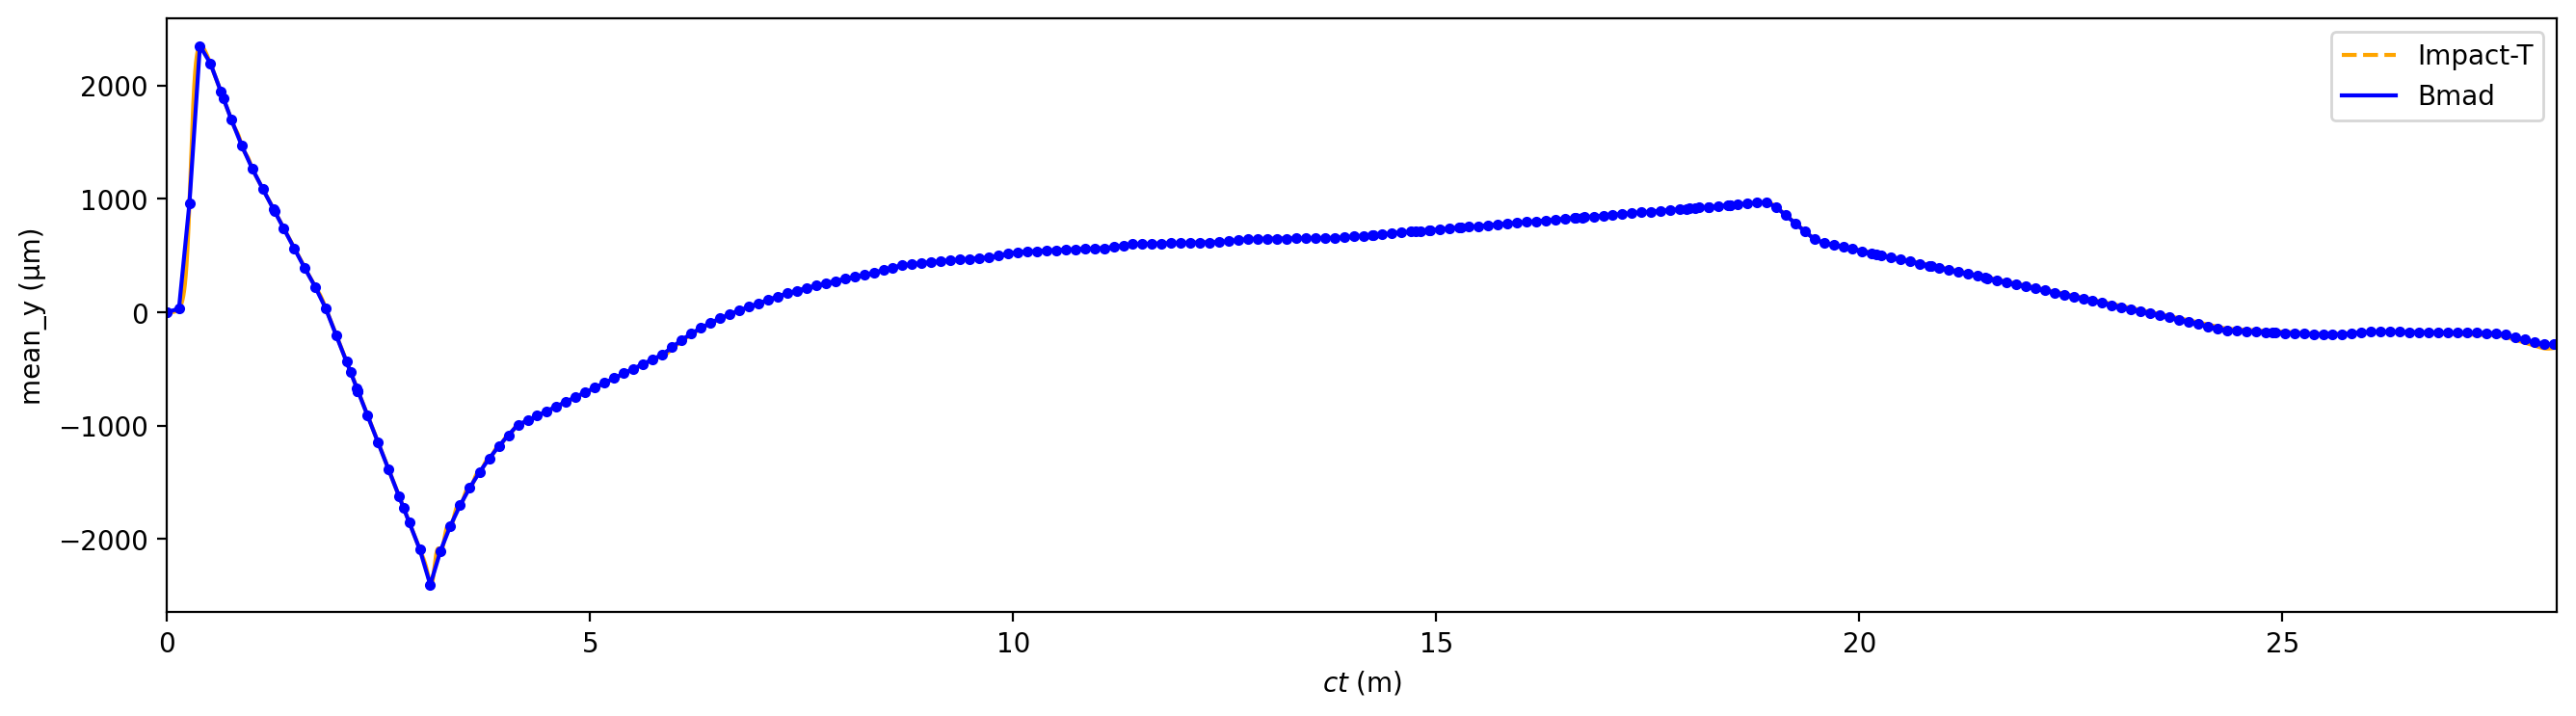

In [24]:
compare('mean_y', yscale = 1e6, yunit = r'µm')

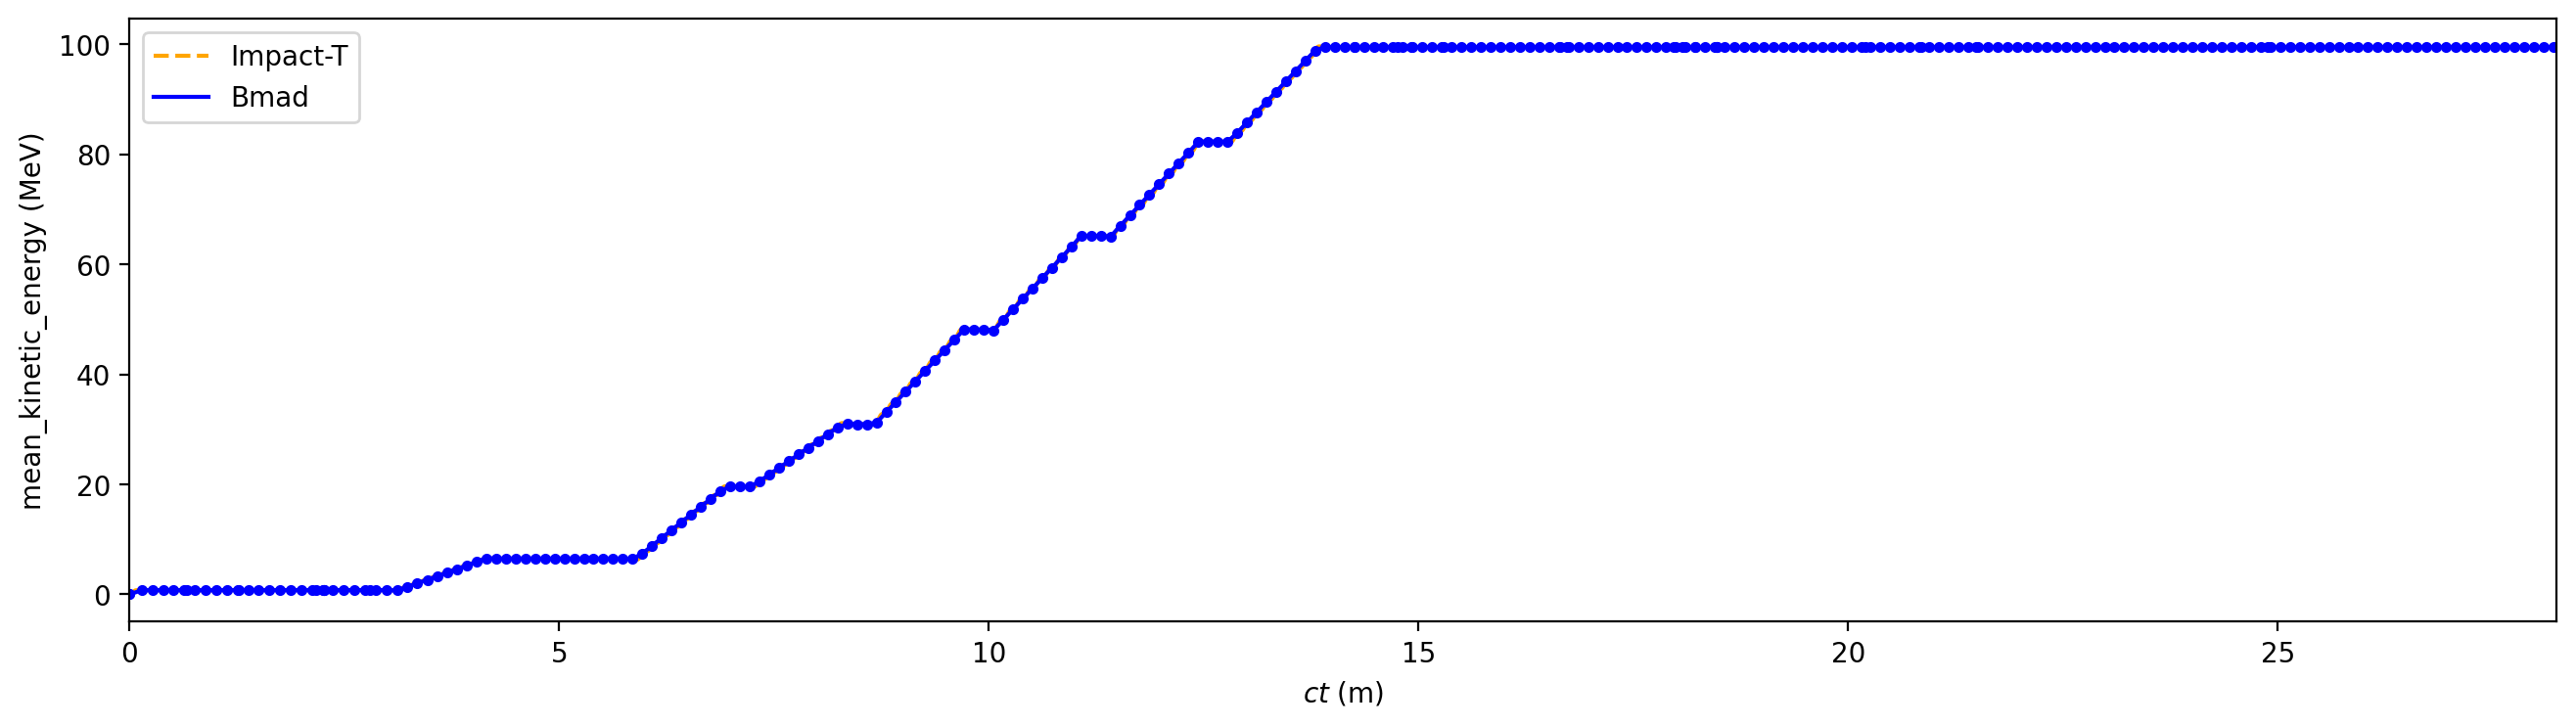

In [25]:
compare('mean_kinetic_energy', yscale=1e-6, yunit='MeV')

# Check phasing

In [26]:
cavs = tao.lat_list('LCAVITY::*', 'ele.name', flags='-no_slaves')
phi0s = [tao.ele_gen_attribs(x)['PHI0'] for x in cavs]

PHASING = {k:v*360 for k, v in zip(cavs, phi0s)}
PHASING

{'BUN1B': -88.49999999999987,
 'CAVL011': 7.999999999999991,
 'CAVL012': -9.0,
 'CAVL013': -20.000000000000018,
 'CAVL014': 25.999999999999993,
 'CAVL015': 0.0,
 'CAVL016': -7.999999999999991,
 'CAVL017': 0.0,
 'CAVL018': 0.0}

In [27]:
I.autophase()

{'RFGUNB': 8.444972822210161,
 'BUN1B': -88.46829862516495,
 'CAVL011': 7.969517731306496,
 'CAVL012': 108.5845212881793,
 'CAVL013': -19.91531452555307,
 'CAVL014': 26.038713958575045,
 'CAVL015': 0.04389038012880064,
 'CAVL016': -7.96227373206068,
 'CAVL017': 0.046871459595763554,
 'CAVL018': 0.09236293755043334}